## Aravind's Contribution

### Importing Libraries

In [13]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, utils
from diffusers import UNet2DModel, DDIMScheduler
from tqdm import tqdm

### Config 

In [14]:
image_size = 64
batch_size = 16
epochs = 10
device = "cuda" if torch.cuda.is_available() else "cpu"
data_path = "ddim_train_5000_per_class"
save_dir = "ddim_outputs/generated_fakes"
os.makedirs(save_dir, exist_ok=True)

### Transforms 

In [15]:
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

### Dataset 

In [16]:
dataset = datasets.ImageFolder(data_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

### Model 

In [17]:
model = UNet2DModel(
    sample_size=image_size,
    in_channels=3,
    out_channels=3,
    layers_per_block=1,
    block_out_channels=(32, 64, 64),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D")
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = DDIMScheduler(num_train_timesteps=1000)

### Training 

In [19]:
model.train()
for epoch in range(epochs):
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    for x, _ in pbar:
        x = x.to(device)
        noise = torch.randn_like(x)
        t = torch.randint(0, scheduler.config.num_train_timesteps, (x.size(0),), device=device).long()
        x_noisy = scheduler.add_noise(x, noise, t)

        noise_pred = model(x_noisy, t).sample
        loss = nn.functional.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=loss.item())

Epoch 10/10: 100%|████████████████████████████████████████████████████| 1563/1563 [02:13<00:00, 11.74it/s, loss=0.0552]


In [20]:
torch.save(model.state_dict(), "ddim_model_trained.pth")

### Sampling: Generate 10 Images per Class

In [22]:
from PIL import Image

model.eval()
scheduler.set_timesteps(50)

n_per_class = 10
class_names = ["drink", "food", "inside", "menu", "outside"]
os.makedirs("ddim_generated", exist_ok=True)

for class_idx, class_name in enumerate(class_names):
    os.makedirs(f"ddim_generated/{class_name}", exist_ok=True)
    for i in range(n_per_class):
        img = torch.randn(1, 3, image_size, image_size).to(device)
        for t in scheduler.timesteps:
            with torch.no_grad():
                noise_pred = model(img, t).sample
            img = scheduler.step(noise_pred, t, img).prev_sample
        final_img = (img.squeeze().cpu().clamp(-1, 1) + 1) / 2
        utils.save_image(final_img, f"ddim_generated/{class_name}/img_{i+1}.png")

In [23]:
import os
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

### Evaluation Code

In [29]:
def load_images_from_class_folders_uint8(root_dir, max_images=10):
    images = []
    class_folders = sorted(os.listdir(root_dir))
    for cls in class_folders:
        folder = os.path.join(root_dir, cls)
        files = sorted(os.listdir(folder))[:max_images]
        for file in files:
            img_path = os.path.join(folder, file)
            img = Image.open(img_path).convert('RGB')
            img = transform(img) * 255        # convert to [0, 255]
            img = img.byte()                  # convert to uint8
            images.append(img)
    return torch.stack(images)

In [30]:
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor()
])

In [31]:
real_images = load_images_from_class_folders_uint8(real_root, max_images=10).to(device)
fake_images = load_images_from_class_folders_uint8(fake_root, max_images=10).to(device)

### Inception Score

In [32]:
is_metric = InceptionScore().to(device)
is_metric.update(fake_images)
is_mean, is_std = is_metric.compute()
print(f"Inception Score: {is_mean:.3f} ± {is_std:.3f}")

Inception Score: 1.877 ± 0.239


### FID Score

In [33]:
fid_metric = FrechetInceptionDistance(feature=2048).to(device)

fid_metric.update(real_images, real=True)
fid_metric.update(fake_images, real=False)
fid_score = fid_metric.compute()
print(f"FID Score: {fid_score:.2f}")

FID Score: 344.43


##  DDIM Model Evaluation

After training the DDIM model using 1,000 images per class (drink, food, inside, menu, outside) totalling 5000 images and generating 10 images per class, the following evaluation metrics were obtained using a pretrained DDIM model:

###  Evaluation Metrics

| **Metric**          | **Score**          |
|---------------------|--------------------|
| Inception Score     | **1.877 ± 0.239**   |
| Frechet Inception Distance (FID) | **344.43**  |

---

###  Evaluation Notes

- **Inception Score (IS)** measures both the quality and diversity of generated images.
- **FID Score** compares the distribution of generated images to real images. Lower is better.
- These metrics indicate a reasonable performance for initial DDIM training.

Showing images for class: food


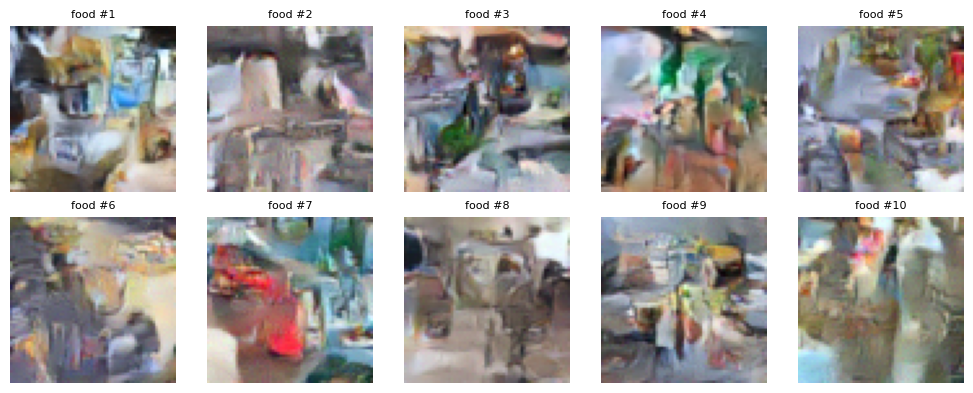

Showing images for class: drink


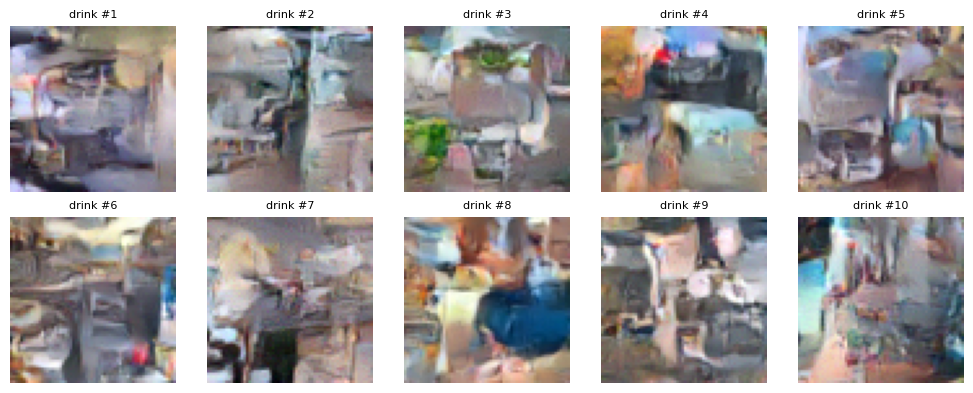

Showing images for class: menu


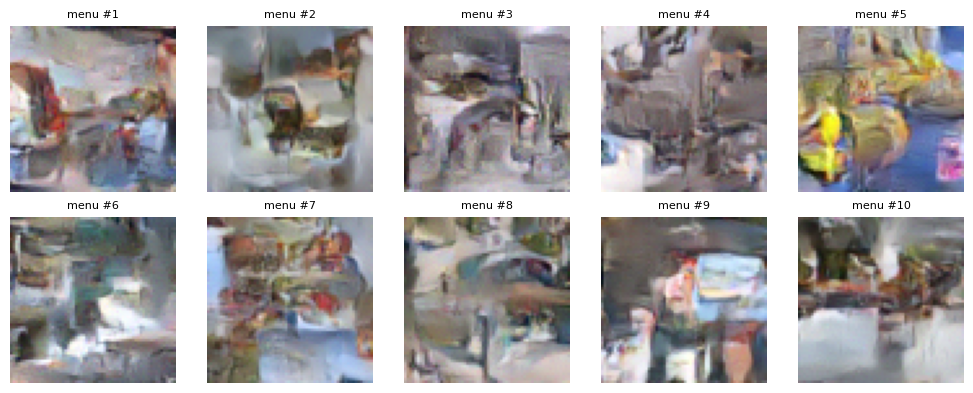

Showing images for class: inside


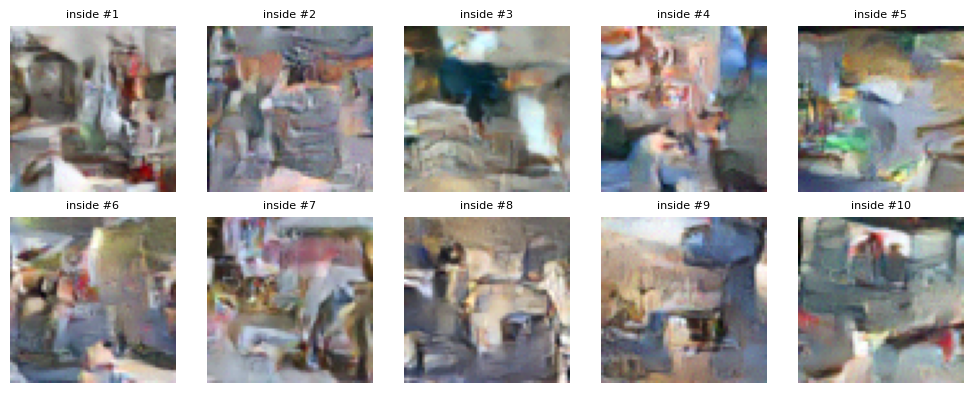

Showing images for class: outside


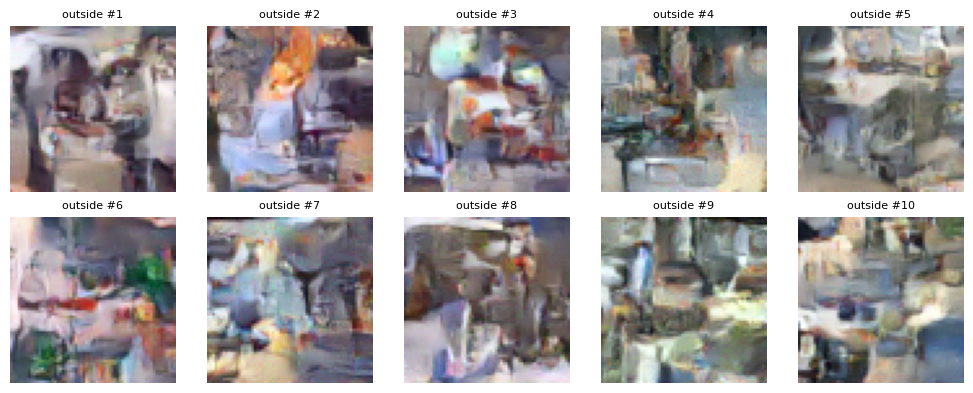

In [36]:
#### import os
import matplotlib.pyplot as plt
from PIL import Image

def display_images_from_class_folder(base_dir, class_name, images_per_row=5):
    class_path = os.path.join(base_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if f.endswith((".png", ".jpg", ".jpeg"))]

    total_images = len(image_files)
    rows = (total_images + images_per_row - 1) // images_per_row

    fig, axes = plt.subplots(rows, images_per_row, figsize=(images_per_row * 2, rows * 2))
    axes = axes.flatten()

    for i in range(rows * images_per_row):
        ax = axes[i]
        if i < total_images:
            img_path = os.path.join(class_path, image_files[i])
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(f"{class_name} #{i+1}", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

#  Set the base directory that contains class folders
base_directory = "ddim_generated"  

#  List of class folders
class_labels = ["food", "drink", "menu", "inside", "outside"]

#  Display images from each class
for class_label in class_labels:
    print(f"Showing images for class: {class_label}")
    display_images_from_class_folder(base_directory, class_label)

## LLM Prompts
- First: How to I initialize to train DDIM mode
- Last: Display all images in block